# FashionIQ
## Business Insights (Notebook 04)

**Project**: FashionIQ — End-to-End Fashion Sales Analytics

**Purpose**: translate the validated patterns produced in `03_eda.ipynb` into business insights,
prioritised by evidence strength, and into recommendations that follow directly from that evidence.

**Source of truth**: every number in this notebook either appears in `03_eda.ipynb` or is
recomputed here from the same cleaned dataset (`data/processed/fashion_sales_clean.csv`) using the
grain rules and metric definitions established in that notebook. No finding is introduced that the
EDA did not establish.

---
## Project Metadata

- **Notebook**: `04_business_insights.ipynb`
- **Project**: FashionIQ
- **Input**: `data/processed/fashion_sales_clean.csv` (read-only)
- **Upstream**: `01_data_understanding.ipynb`, `02_data_cleaning.ipynb`, `03_eda.ipynb`
- **Scope**: interpretation and recommendation. No data cleaning, no new exploratory sweeps.
- **Runs independently**: this notebook does not reuse any variable from `03_eda.ipynb`; it rebuilds
  the small number of aggregations it needs from the cleaned file.

---
## 01. Project Context

FashionIQ is a multi-platform Indonesian fashion retailer selling across 5 platforms, 38 cities and
20 product types. The cleaned dataset covers one calendar year (2025) of **order-item level**
transactions: 15,000 line items belonging to 5,000 orders.

**The business problem**: the company records sales across several channels, a wide city footprint
and a 20-product catalogue, but has no evidence-based view of *which of those dimensions actually
differentiates performance*. Without that, reporting effort and commercial attention get spread
evenly across dimensions that behave very differently.

**What the EDA investigated** (`03_eda.ipynb`): overall sales scale and its movement over the year,
order-status composition, and performance by platform, city, product, category/material/gender,
customer rating, discount behaviour and order economics — each with an explicit statement of what
the evidence does and does not support.

**What this notebook does**: selects the EDA findings strong enough to act on, states what they
imply for the business, and specifies what should be monitored. It stops where the evidence stops.

---
## 02. Objective

This notebook moves each qualifying EDA finding along a fixed chain:

```
Evidence  ->  Interpretation  ->  Business Insight  ->  Potential Action
```

Three properties of that chain are held throughout:

1. **Observation, insight and recommendation are kept separate.** An observation is what the data
   shows; an insight is what the observation means analytically; a recommendation is what the
   business could consider doing. They are never collapsed into one sentence.
2. **The analysis remains observational.** This is a single cross-sectional year of transaction
   records with no experiment, no control group, no campaign log and no cost data. Every
   relationship reported here is an *association*. Language such as "associated with", "tracks" and
   "appears to be" is used deliberately; "causes", "drives" and "leads to" are not used.
3. **A negative finding is a finding.** Where the EDA showed that a relationship is weak or absent,
   that is reported as a result rather than reworked until something appears.

---
## Setup — load the cleaned dataset and rebuild the order-level view

*Why*: the EDA established that this dataset is **order-item grain** (one row = one product line,
not one order) and that several fields — `Order Status`, `Platform`, `City`, `Customer Rating`,
`Shipping Fee`, `Grand Total` — are order-level attributes repeated across every line of an order.
Summing those at row level double-counts them, and `len(df)` is a line count, never an order count.

This notebook therefore rebuilds the same `order_df` view used in `03_eda.ipynb` (one row per
`Order ID`) and uses it for every order-level metric.

In [ ]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 130)


def resolve_processed_path(filename: str = 'fashion_sales_clean.csv',
                           project_dir_name: str = 'fashion-sales-analytics-pipeline') -> Path:
    """Locate data/processed/<filename> regardless of the notebook's working directory.

    Same project-root discovery used in 03_eda.ipynb: Jupyter/VS Code may start the kernel in the
    notebook folder, the project root, or a workspace folder that merely contains the project, so a
    single relative path is not portable.
    """
    marker = Path('data') / 'processed' / filename
    cwd = Path.cwd().resolve()
    search_dirs = [cwd, *cwd.parents]

    for candidate in search_dirs:
        if (candidate / marker).exists():
            return candidate / marker
    for candidate in search_dirs:
        if (candidate / project_dir_name / marker).exists():
            return candidate / project_dir_name / marker

    raise FileNotFoundError(
        f"Could not locate '{marker}' by searching upward from '{cwd}', including inside a "
        f"'{project_dir_name}' subfolder. Run this notebook from within the FashionIQ project."
    )


PROCESSED_PATH = resolve_processed_path()
df = pd.read_csv(PROCESSED_PATH, parse_dates=['Order Date'])
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns  |  {PROCESSED_PATH}')

# Guard: this notebook's numbers are stated against the dataset validated in 02/03.
assert df.shape == (15000, 20), f'Unexpected shape {df.shape}; numbers in this notebook assume (15000, 20).'
assert df.isna().sum().sum() == 0, 'Unexpected missing values; 02_data_cleaning.ipynb baseline was zero.'

Loaded: 15,000 rows x 20 columns  |  C:\Users\ASUS GAMING\VSCode\fashion-sales-analytics-pipeline\data\processed\fashion_sales_clean.csv


In [ ]:
# Order-level view: one row per Order ID (identical construction to 03_eda.ipynb section 5.3)
order_df = (
    df.groupby('Order ID')
      .agg(
          Order_Date=('Order Date', 'first'),
          City=('City', 'first'),
          Platform=('Platform', 'first'),
          Order_Status=('Order Status', 'first'),
          Customer_Rating=('Customer Rating', 'first'),
          Shipping_Fee=('Shipping Fee', 'first'),
          Grand_Total=('Grand Total', 'first'),
          Total_Sales=('Total Sales', 'sum'),
          Quantity=('Quantity', 'sum'),
          Line_Items=('Product Name', 'count'),
      )
      .reset_index()
)

# Order-level discount rate (line-item Discount Amount summed against line-item Subtotal)
order_discount = df.groupby('Order ID').agg(
    order_discount_amount=('Discount Amount', 'sum'),
    order_subtotal=('Subtotal', 'sum'),
).reset_index()
order_discount['order_discount_rate'] = (
    order_discount['order_discount_amount'] / order_discount['order_subtotal'].replace(0, np.nan)
)
order_df = order_df.merge(order_discount[['Order ID', 'order_discount_rate']], on='Order ID', how='left')

assert len(order_df) == df['Order ID'].nunique() == 5000
assert (order_df['Grand_Total'] != order_df['Total_Sales'] + order_df['Shipping_Fee']).sum() == 0

print(f'order_df: {order_df.shape[0]:,} orders x {order_df.shape[1]} columns (one row per Order ID)')

order_df: 5,000 orders x 12 columns (one row per Order ID)


In [ ]:
def rupiah_axis(ax, axis: str = 'y') -> None:
    """Format an axis in millions of Rupiah (same helper style as 03_eda.ipynb)."""
    fmt = mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.0f}M')
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(fmt)


def cohen_r_label(r: float) -> str:
    """Cohen (1988) conventional thresholds, used identically in 03_eda.ipynb."""
    a = abs(r)
    return 'negligible' if a < 0.1 else 'weak' if a < 0.3 else 'moderate' if a < 0.5 else 'strong'


def rp(x) -> str:
    return f'Rp {x:,.0f}'


PLOT_COLORS = {'primary': '#2c3e50', 'accent': '#16a085', 'warm': '#e67e22',
               'cool': '#2980b9', 'muted': '#95a5a6', 'alert': '#c0392b'}

In [ ]:
# Headline figures, recomputed from the cleaned file (03_eda.ipynb section 7.1)
order_count = df['Order ID'].nunique()
recorded_sales = int(df['Total Sales'].sum())
units_sold = int(df['Quantity'].sum())
sales_aov = recorded_sales / order_count
completed_sales = int(order_df.loc[order_df['Order_Status'] == 'Completed', 'Total_Sales'].sum())
non_completed_sales = recorded_sales - completed_sales

headline = pd.DataFrame({
    'metric': ['Line items', 'Orders', 'Units sold', 'Recorded sales (all statuses)',
               'Recorded sales (Completed only)', 'Sales AOV (excl. shipping)',
               'Line items per order', 'Units per order'],
    'value': [f'{len(df):,}', f'{order_count:,}', f'{units_sold:,}', rp(recorded_sales),
              rp(completed_sales), rp(sales_aov),
              f'{len(df)/order_count:.2f}', f'{units_sold/order_count:.2f}'],
})
print('FashionIQ 2025 - headline figures')
display(headline)
print(f'\nNon-completed orders hold {rp(non_completed_sales)} '
      f'({non_completed_sales/recorded_sales*100:.1f}% of recorded sales).')

FashionIQ 2025 - headline figures


,metric,value
0,Line items,"15,000"
1,Orders,"5,000"
2,Units sold,"26,453"
3,Recorded sales (all statuses),"Rp 6,975,804,400"
4,Recorded sales (Completed only),"Rp 4,794,773,200"
5,Sales AOV (excl. shipping),"Rp 1,395,161"
6,Line items per order,3.00
7,Units per order,5.29



Non-completed orders hold Rp 2,181,031,200 (31.3% of recorded sales).


---
## 03. EDA Findings Recap

The table below summarises what `03_eda.ipynb` established. It introduces no new analysis — every
row points back to a section of that notebook. Section references are to `03_eda.ipynb`.

| Area | Key Finding | Evidence |
|---|---|---|
| **Sales** | Recorded activity is flat across 2025 — no growth, no decline, no confirmed seasonality | Monthly sales CoV 4.7%, orders CoV 4.5%, AOV CoV 1.9%; high-to-low sales spread 14.2% (Rp 542.2M in Sep to Rp 619.2M in Oct) — §7.2–7.5 |
| **Order status** | 31.4% of orders never reach `Completed`, and order value is uniform across statuses | Completed 3,430 orders (68.6% of orders / 68.7% of sales); Returned 13.9%, Cancelled 7.4%, Shipped 5.3%, Pending 4.8%; avg Grand Total by status spans only Rp 1,339,425–1,472,556 — §8.1–8.3 |
| **Platform** | Sales ranking follows order-count ranking exactly; AOV barely differentiates platforms | corr(order count, sales) = **1.000** vs corr(AOV, sales) = 0.218 across 5 platforms; AOV band Rp 1,367,215–1,414,191 against a 3.9× sales range — §9, §16.1 |
| **Geography** | Sales are spread thinly across the city base, not concentrated in metros | Top 3 cities = 13.1% of sales (an even split across 38 cities would give 7.9%); top city Jakarta holds 4.9% — §10 |
| **Product** | Moderate concentration; recorded sales track unit *price* far more than unit *volume* | Top 5 products = 34.5%, top 10 = 60.9% of sales across 20 products; corr(avg unit price, sales) = **0.864**, corr(quantity, sales) = **−0.565**; only 2 of the top 8 by sales are also top 8 by quantity — §11, §16.2 |
| **Category** | Tops lead the derived category mix; the gender split is a property of the taxonomy, not of customers | Tops 39.6%, Bottoms 25.3%, Dresses 19.9%, Outerwear 12.7%, Accessories 2.5%; 4 of 5 categories skew >65/35 by `Gender`, but `Gender` is a **product** attribute and `Category` is analyst-derived — §12 |
| **Rating** | Rating shows no association with order value and almost no spread across platforms or statuses | corr(rating, Grand Total) = **0.004** (negligible); platform means 2.815–3.073 (spread 0.258 on a 1–5 scale); status means 2.916–3.091; 59.4% of orders rated ≤3 — §13 |
| **Discount** | Discounting is rare, uniform, and not associated with larger baskets | 95.2% of orders carry no discount; `Discount (%)` takes only two values (0 and 10); discounted orders avg Grand Total Rp 1,292,861 vs Rp 1,424,532; corr(rate, units) = −0.007, corr(rate, Grand Total) = −0.050 — §14 |
| **Order economics** | Order value is flatly distributed and baskets are structurally multi-line | Top 10% of orders by value = 17.6% of total order value; every order carries 2–4 line items (1,500 / 2,000 / 1,500 orders) at 1.76 units per line; shipping Rp 17,000–27,000, mean Rp 23,025 — §15 |

**One cross-cutting caveat applies to every "sales" figure below.** Recorded sales includes all order
statuses. Because 31.3% of that value sits in non-completed orders *and* order value is essentially
uniform across statuses, the caveat scales every breakdown proportionally rather than distorting any
one of them — which is why the EDA labelled the metric **"recorded sales"** rather than "revenue"
throughout, and why this notebook keeps that label.

---
## 04. Insight 1 — Platform Economics

### Business Question
Is platform sales performance primarily a **volume** story, a **basket-value** story, or a
combination of the two? The distinction matters because it determines whether channel management
should be framed around reach and order acquisition or around basket quality.

### Evidence

Platform KPIs are computed at order level. One correction is applied: the platform table in
`03_eda.ipynb` §9 reported `avg_units_per_order` as `NaN` — the value was assigned from a
`Platform`-indexed Series onto a positionally-indexed frame, so it never aligned. That column is
recomputed correctly here from the same cleaned data. Every other figure matches the EDA output.

In [ ]:
platform_econ = order_df.groupby('Platform').agg(
    order_count=('Order ID', 'nunique'),
    recorded_sales=('Total_Sales', 'sum'),
    units=('Quantity', 'sum'),
    line_items=('Line_Items', 'sum'),
).reset_index()

platform_econ['aov'] = (platform_econ['recorded_sales'] / platform_econ['order_count']).round(0)
platform_econ['units_per_order'] = (platform_econ['units'] / platform_econ['order_count']).round(2)
platform_econ['order_share_pct'] = (platform_econ['order_count'] / platform_econ['order_count'].sum() * 100).round(1)
platform_econ['sales_share_pct'] = (platform_econ['recorded_sales'] / platform_econ['recorded_sales'].sum() * 100).round(1)

# Line-item discount rate by platform (Discount Amount is a line-item field)
platform_disc = (
    df.assign(discount_rate=lambda x: x['Discount Amount'] / x['Subtotal'].replace(0, np.nan))
      .groupby('Platform')['discount_rate'].mean().round(4).reset_index()
      .rename(columns={'discount_rate': 'avg_discount_rate'})
)
platform_econ = platform_econ.merge(platform_disc, on='Platform')
platform_econ = platform_econ.sort_values('recorded_sales', ascending=False).reset_index(drop=True)

print('Platform economics - volume, basket value and discount side by side')
display(platform_econ[['Platform', 'order_count', 'order_share_pct', 'recorded_sales',
                       'sales_share_pct', 'aov', 'units_per_order', 'avg_discount_rate']])

vol_corr = platform_econ['order_count'].corr(platform_econ['recorded_sales'])
aov_corr = platform_econ['aov'].corr(platform_econ['recorded_sales'])
print(f"\ncorr(order count, recorded sales) = {vol_corr:.3f} ({cohen_r_label(vol_corr)})")
print(f"corr(AOV,         recorded sales) = {aov_corr:.3f} ({cohen_r_label(aov_corr)})")
print(f"\nRecorded sales range across platforms: {platform_econ['recorded_sales'].max()/platform_econ['recorded_sales'].min():.2f}x")
print(f"Order count range across platforms:    {platform_econ['order_count'].max()/platform_econ['order_count'].min():.2f}x")
print(f"AOV range across platforms:            {platform_econ['aov'].max()/platform_econ['aov'].min():.3f}x "
      f"({rp(platform_econ['aov'].min())} to {rp(platform_econ['aov'].max())})")
print(f"Units per order range:                 {platform_econ['units_per_order'].min():.2f} to {platform_econ['units_per_order'].max():.2f}")

Platform economics - volume, basket value and discount side by side


,Platform,order_count,order_share_pct,recorded_sales,sales_share_pct,aov,units_per_order,avg_discount_rate
0,Toko Fashion App,1753,35.1,2459498600,35.3,1403023.0,5.36,0.0046
1,StyleMart,1134,22.7,1550422300,22.2,1367215.0,5.18,0.0038
2,FashionKita,1000,20.0,1414191200,20.3,1414191.0,5.34,0.0056
3,OutfitNow,658,13.2,923708300,13.2,1403812.0,5.32,0.0051
4,FashionHub,455,9.1,627984000,9.0,1380185.0,5.16,0.0059



corr(order count, recorded sales) = 1.000 (strong)
corr(AOV,         recorded sales) = 0.218 (weak)

Recorded sales range across platforms: 3.92x
Order count range across platforms:    3.85x
AOV range across platforms:            1.034x (Rp 1,367,215 to Rp 1,414,191)
Units per order range:                 5.16 to 5.36


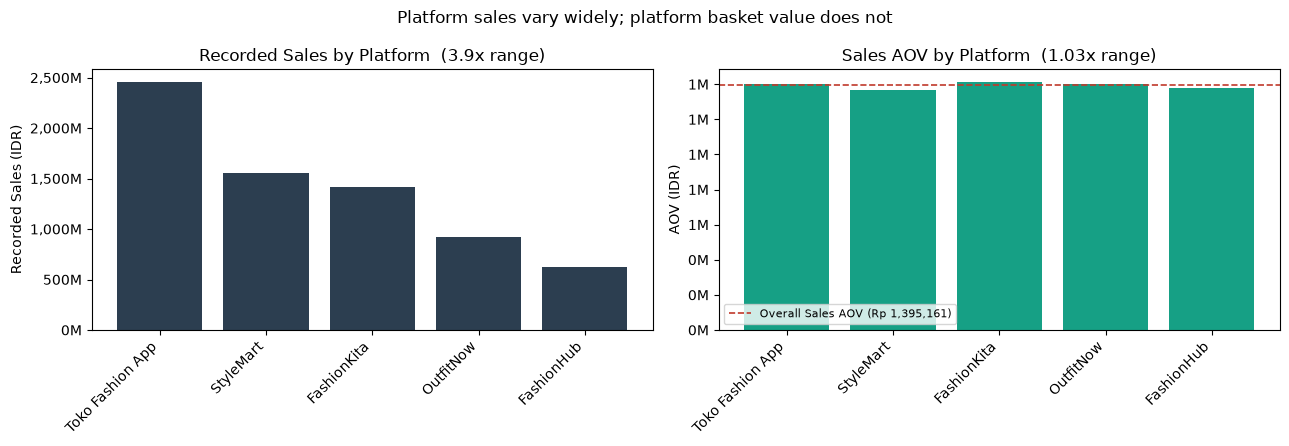

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(platform_econ['Platform'], platform_econ['recorded_sales'], color=PLOT_COLORS['primary'])
axes[0].set_title('Recorded Sales by Platform  (3.9x range)')
axes[0].set_ylabel('Recorded Sales (IDR)')
rupiah_axis(axes[0])
axes[0].tick_params(axis='x', rotation=45)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha('right')

axes[1].bar(platform_econ['Platform'], platform_econ['aov'], color=PLOT_COLORS['accent'])
axes[1].axhline(sales_aov, color=PLOT_COLORS['alert'], linestyle='--', linewidth=1.2,
                label=f'Overall Sales AOV ({rp(sales_aov)})')
axes[1].set_title('Sales AOV by Platform  (1.03x range)')
axes[1].set_ylabel('AOV (IDR)')
rupiah_axis(axes[1])
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha('right')

fig.suptitle('Platform sales vary widely; platform basket value does not', fontsize=12)
plt.tight_layout()
plt.show()

### Observation

Recorded sales differ by a factor of **3.92** across the five platforms — Toko Fashion App records
Rp 2,459,498,600 against FashionHub's Rp 627,984,000. Order counts differ by an almost identical
factor of **3.85** (1,753 vs 455 orders). Sales AOV, by contrast, differs by a factor of **1.03**:
the entire band runs from Rp 1,367,215 (StyleMart) to Rp 1,414,191 (FashionKita), a 3.4% spread
around an overall Sales AOV of Rp 1,395,161. Units per order sit between 5.16 and 5.36 across all
five platforms. The rank correlation is unambiguous: corr(order count, recorded sales) = **1.000**,
while corr(AOV, recorded sales) = 0.218 (weak).

Toko Fashion App holds 35.1% of orders and 35.3% of recorded sales — the two shares are the same
number to within a rounding difference.

### Interpretation

Platform sales leadership in this dataset is **volume-determined, not basket-determined**. The
correlation of 1.000 means the sales ranking and the order-count ranking are the same ranking; there
is no platform whose position is explained by customers spending more per order. FashionKita has the
highest AOV of the five, but at Rp 1,414,191 it sits only 1.4% above the overall average and 3.4%
above the lowest platform — a gap too small to describe as a different basket-value profile. The
more defensible reading is that **all five platforms sell essentially the same basket**, and what
separates them is how many of those baskets each one processes.

The near-identical order share and sales share for the top platform is the same statement from
another angle: the platform contributes exactly the proportion of revenue its order volume implies,
with no value premium or discount attached.

### Business Implication

Channel performance should be framed as a **distribution and order-acquisition question**, not a
basket-quality question. Comparing platforms on AOV will surface differences of a few percent that
carry no reliable signal, and ranking platforms by sales adds nothing that ranking them by order
count does not already say. The one figure that does carry business weight is **concentration**:
a single platform accounts for roughly a third of all orders and a third of recorded sales, which is
a dependency worth measuring explicitly rather than leaving implicit in a sales chart.

### Caveat

Five platforms is a very small n. The correlation of 1.000 should be read as a description of the
rank alignment across these five observations, not as a statistically robust estimate — with n=5, a
single platform moving would change it materially. The dataset also contains no information about
platform commission, fulfilment cost, customer acquisition spend or contract terms, so nothing here
speaks to which platform is *worth* more to the business — only to which processes more orders.

---
## 05. Insight 2 — Product Performance & Concentration

### Business Question
Are recorded sales concentrated among a small number of products or spread across the catalogue —
and do the products that generate the most sales also move the most units?

In [ ]:
product_econ = df.groupby('Product Name').agg(
    total_sales=('Total Sales', 'sum'),
    total_qty=('Quantity', 'sum'),
    avg_unit_price=('Unit Price', 'mean'),
).reset_index()
product_econ['sales_share_pct'] = (product_econ['total_sales'] / product_econ['total_sales'].sum() * 100).round(2)
product_econ['avg_unit_price'] = product_econ['avg_unit_price'].round(0)
product_econ = product_econ.sort_values('total_sales', ascending=False).reset_index(drop=True)

n_products = len(product_econ)
top5_share = product_econ.head(5)['total_sales'].sum() / product_econ['total_sales'].sum() * 100
top10_share = product_econ.head(10)['total_sales'].sum() / product_econ['total_sales'].sum() * 100

qty_corr = product_econ['total_qty'].corr(product_econ['total_sales'])
price_corr = product_econ['avg_unit_price'].corr(product_econ['total_sales'])

N = 8
sales_leaders = product_econ.head(N)
qty_leaders = product_econ.sort_values('total_qty', ascending=False).head(N)
overlap = sorted(set(sales_leaders['Product Name']) & set(qty_leaders['Product Name']))

print(f'Top {N} products by RECORDED SALES')
display(sales_leaders[['Product Name', 'total_sales', 'sales_share_pct', 'total_qty', 'avg_unit_price']])
print(f'Top {N} products by QUANTITY SOLD')
display(qty_leaders[['Product Name', 'total_qty', 'total_sales', 'sales_share_pct', 'avg_unit_price']])

print(f'Overlap: {len(overlap)} of the top {N} by sales are also top {N} by quantity -> {overlap}')
print(f'\nConcentration across {n_products} products:')
print(f'  Top 5  = {top5_share:.1f}% of recorded sales  (an even split would give 5/{n_products} = {500/n_products:.1f}%)')
print(f'  Top 10 = {top10_share:.1f}% of recorded sales  (an even split would give 10/{n_products} = {1000/n_products:.1f}%)')
print(f'  Product sales share ranges from {product_econ["sales_share_pct"].min():.2f}% to {product_econ["sales_share_pct"].max():.2f}%')
print(f'\ncorr(quantity,       recorded sales) = {qty_corr:.3f} ({cohen_r_label(qty_corr)})')
print(f'corr(avg unit price, recorded sales) = {price_corr:.3f} ({cohen_r_label(price_corr)})')

Top 8 products by RECORDED SALES


,Product Name,total_sales,sales_share_pct,total_qty,avg_unit_price
0,Gamis,619178000,8.88,1191,518259.0
1,Jaket Denim,478830300,6.86,1117,431622.0
2,Celana Jeans,477506000,6.85,1163,413151.0
3,Dress Formal,427203100,6.12,716,599458.0
4,Jaket Bomber,406594800,5.83,1132,360915.0
5,Rok Midi,385007200,5.52,1375,280237.0
6,Kemeja Casual,375000500,5.38,1549,242690.0
7,Blouse,373209300,5.35,1487,251545.0


Top 8 products by QUANTITY SOLD


,Product Name,total_qty,total_sales,sales_share_pct,avg_unit_price
18,Kaos Pendek,1882,204052500,2.93,109291.0
19,Hijab,1873,172154600,2.47,92429.0
12,Celana Pendek,1857,321030300,4.60,175230.0
6,Kemeja Casual,1549,375000500,5.38,242690.0
17,Kaos Panjang,1547,207068500,2.97,133811.0
7,Blouse,1487,373209300,5.35,251545.0
16,Legging,1483,263072800,3.77,179694.0
15,Kaos Polo,1441,279674700,4.01,195755.0


Overlap: 2 of the top 8 by sales are also top 8 by quantity -> ['Blouse', 'Kemeja Casual']

Concentration across 20 products:
  Top 5  = 34.5% of recorded sales  (an even split would give 5/20 = 25.0%)
  Top 10 = 60.9% of recorded sales  (an even split would give 10/20 = 50.0%)
  Product sales share ranges from 2.47% to 8.88%

corr(quantity,       recorded sales) = -0.565 (strong)
corr(avg unit price, recorded sales) = 0.864 (strong)


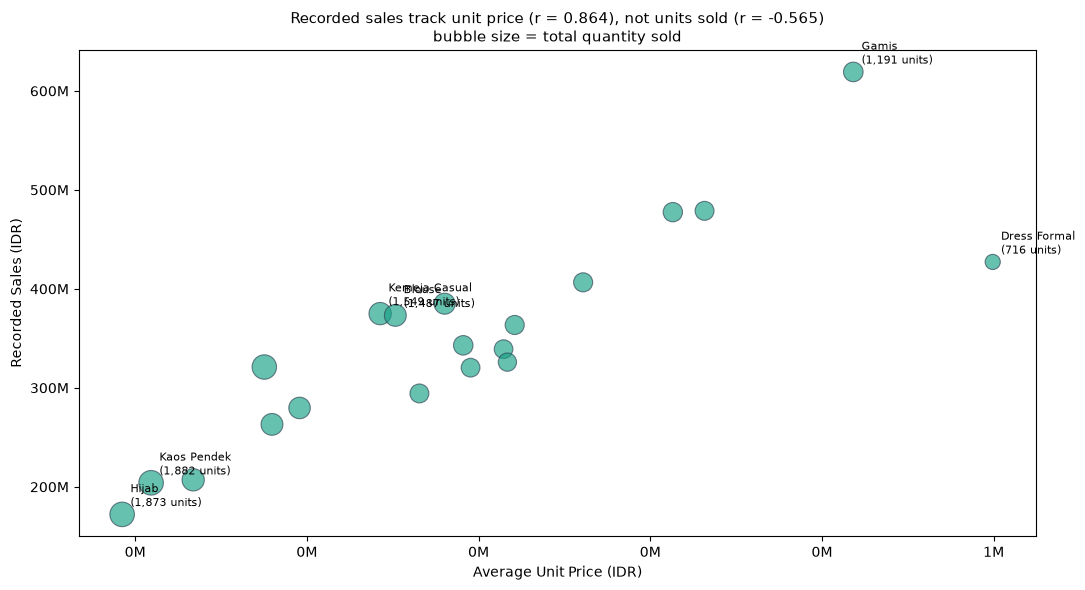

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(product_econ['avg_unit_price'], product_econ['total_sales'],
           s=product_econ['total_qty'] / 6, alpha=0.65, color=PLOT_COLORS['accent'],
           edgecolor=PLOT_COLORS['primary'], linewidth=0.8)

highlight = ['Gamis', 'Dress Formal', 'Kaos Pendek', 'Hijab', 'Kemeja Casual', 'Blouse']
for _, r in product_econ[product_econ['Product Name'].isin(highlight)].iterrows():
    ax.annotate(f"{r['Product Name']}\n({int(r['total_qty']):,} units)",
                (r['avg_unit_price'], r['total_sales']),
                fontsize=8, xytext=(6, 6), textcoords='offset points')

ax.set_title(f'Recorded sales track unit price (r = {price_corr:.3f}), not units sold (r = {qty_corr:.3f})\n'
             'bubble size = total quantity sold', fontsize=11)
ax.set_xlabel('Average Unit Price (IDR)')
ax.set_ylabel('Recorded Sales (IDR)')
rupiah_axis(ax, axis='x')
rupiah_axis(ax, axis='y')
plt.tight_layout()
plt.show()

### Observation

Across 20 products, the top 5 account for **34.5%** of recorded sales and the top 10 for **60.9%**.
An even split would place those groups at 25.0% and 50.0% respectively. Individual product shares
run from 2.47% (Hijab) to 8.88% (Gamis) — a range of roughly 3.6× between the smallest and largest
contributor, against an even-split expectation of 5.0% each.

The two leaderboards do not agree. Only **2 of the top 8 by sales** (Blouse and Kemeja Casual) also
appear in the top 8 by quantity. Gamis leads recorded sales at Rp 619,178,000 on 1,191 units at an
average unit price of Rp 518,259. Kaos Pendek leads quantity at 1,882 units but generates
Rp 204,052,500 — 2.9% of sales, ranking 19th of 20. Across the catalogue, corr(avg unit price,
recorded sales) = **0.864** (strong) while corr(quantity, recorded sales) = **−0.565** (strong, and
negative).

### Interpretation

Sales concentration is **mild** — meaningfully above an even split, but well short of a business
that depends on a handful of products. The bottom 10 products still carry 39.1% of recorded sales,
so no small group of items can be described as carrying the portfolio.

The more consequential finding is the second one: within this catalogue, **recorded sales are
price-led rather than volume-led**. The negative quantity–sales correlation means the products
moving the most units are systematically the *cheaper* ones, and their unit volume does not
compensate for their price point. This makes "best seller" a genuinely ambiguous term here — a
units-based ranking and a revenue-based ranking identify largely different products, agreeing on
only a quarter of the top 8.

Note that this is a statement about the *observed* price–revenue relationship across products as
they were sold, not about price elasticity. Nothing in this dataset shows what would happen to
volume if any product's price changed.

### Business Implication

Any decision that starts from a single "top products" list is exposed to picking the wrong list.
Merchandising, promotional slotting and inventory-value planning read from revenue contribution;
stock-depth, packing and fulfilment planning read from unit movement. Because the two rankings
overlap on only 2 of 8 products, the business should maintain **both rankings explicitly** and state
which one a given decision is using, rather than reconciling them into one.

### Caveat

There is no cost or margin data in this dataset, so a high-revenue product cannot be called a
profitable one — a high unit price may reflect a higher input cost rather than a better contribution.
For the same reason, no pricing recommendation follows from the 0.864 correlation. The correlations
are computed across 20 products, which is enough to describe the catalogue but small enough that
individual products influence the coefficients noticeably.

---
## 06. Insight 3 — Geographic Performance

### Business Question
Does geographic sales leadership come from transaction volume, from order value, or from both — and
is any city large enough to warrant a differentiated commercial approach?

In [ ]:
city_econ = order_df.groupby('City').agg(
    order_count=('Order ID', 'nunique'),
    recorded_sales=('Total_Sales', 'sum'),
).reset_index()
city_econ['aov'] = (city_econ['recorded_sales'] / city_econ['order_count']).round(0)
city_econ['sales_share_pct'] = (city_econ['recorded_sales'] / city_econ['recorded_sales'].sum() * 100).round(2)
city_econ = city_econ.sort_values('recorded_sales', ascending=False).reset_index(drop=True)

n_cities = len(city_econ)
even_split = 100 / n_cities
top3_share = city_econ.head(3)['sales_share_pct'].sum()
top10_share_city = city_econ.head(10)['sales_share_pct'].sum()

print('Top 10 cities by recorded sales')
display(city_econ.head(10))

top_city = city_econ.iloc[0]
aov_rank_top_city = int((city_econ['aov'] > top_city['aov']).sum() + 1)
print(f"Cities: {n_cities}  |  even split = {even_split:.2f}% each")
print(f"Top 1  ({top_city['City']}): {top_city['sales_share_pct']:.2f}% of recorded sales, "
      f"{int(top_city['order_count'])} orders, AOV {rp(top_city['aov'])}")
print(f"Top 3:  {top3_share:.1f}% (even split would give {3*even_split:.1f}%)")
print(f"Top 10: {top10_share_city:.1f}% (even split would give {10*even_split:.1f}%)")
print(f"\nCity sales share range: {city_econ['sales_share_pct'].min():.2f}% to {city_econ['sales_share_pct'].max():.2f}%")
print(f"City order-count range: {int(city_econ['order_count'].min())} to {int(city_econ['order_count'].max())} "
      f"(mean {city_econ['order_count'].mean():.0f} orders per city)")
print(f"City AOV range: {rp(city_econ['aov'].min())} to {rp(city_econ['aov'].max())}")
print(f"\n{top_city['City']} ranks #{aov_rank_top_city} of {n_cities} on AOV despite ranking #1 on recorded sales.")

Top 10 cities by recorded sales


,City,order_count,recorded_sales,aov,sales_share_pct
0,Jakarta,252,338853800,1344658.0,4.86
1,Pangkalpinang,198,292496400,1477255.0,4.19
2,Semarang,199,284329600,1428792.0,4.08
3,Surabaya,197,268973300,1365347.0,3.86
4,Jayapura,190,267033900,1405442.0,3.83
5,Samarinda,198,263389100,1330248.0,3.78
6,Pontianak,180,255273400,1418186.0,3.66
7,Bandung,174,248107400,1425905.0,3.56
8,Wamena,163,231463100,1420019.0,3.32
9,Bengkulu,159,226642700,1425426.0,3.25


Cities: 38  |  even split = 2.63% each
Top 1  (Jakarta): 4.86% of recorded sales, 252 orders, AOV Rp 1,344,658
Top 3:  13.1% (even split would give 7.9%)
Top 10: 38.4% (even split would give 26.3%)

City sales share range: 1.14% to 4.86%
City order-count range: 58 to 252 (mean 132 orders per city)
City AOV range: Rp 1,293,622 to Rp 1,490,724

Jakarta ranks #34 of 38 on AOV despite ranking #1 on recorded sales.


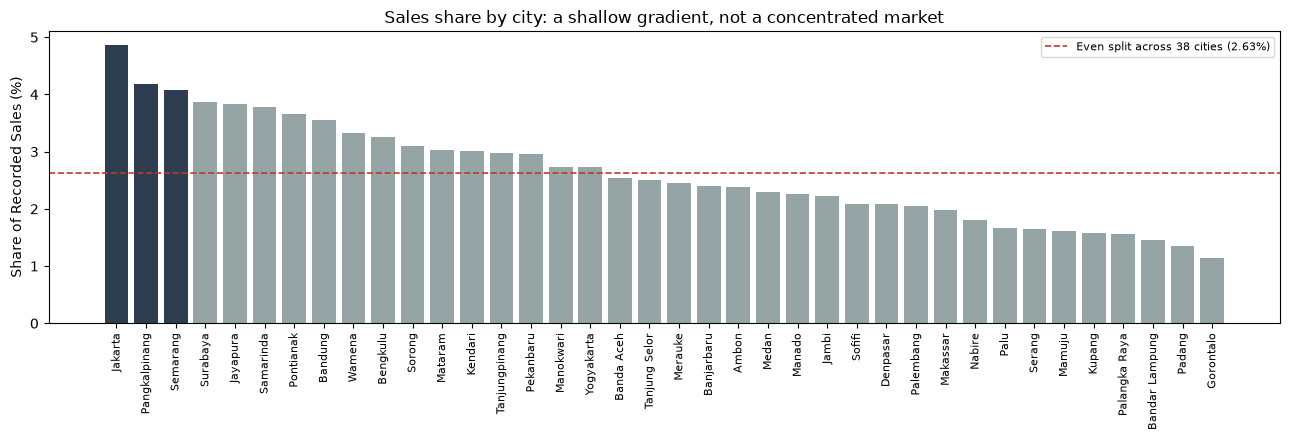

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.5))
colors = [PLOT_COLORS['primary'] if i < 3 else PLOT_COLORS['muted'] for i in range(n_cities)]
ax.bar(city_econ['City'], city_econ['sales_share_pct'], color=colors)
ax.axhline(even_split, color=PLOT_COLORS['alert'], linestyle='--', linewidth=1.2,
           label=f'Even split across {n_cities} cities ({even_split:.2f}%)')
ax.set_title('Sales share by city: a shallow gradient, not a concentrated market')
ax.set_ylabel('Share of Recorded Sales (%)')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=90, labelsize=8)
plt.tight_layout()
plt.show()

### Observation

Recorded sales are distributed across 38 cities with a shallow gradient. The largest city, Jakarta,
holds **4.86%** of recorded sales; the smallest holds 1.14%; an even split would give every city
2.63%. The top 3 cities together account for **13.1%**, against 7.9% under an even split, and the
top 10 account for 38.4% against 26.3%.

Jakarta's position is entirely a volume position. It records the highest order count (252 orders,
against a 38-city mean of 132) but ranks **34th of 38 on AOV** at Rp 1,344,658 — below the overall
Sales AOV of Rp 1,395,161. City-level AOV spans Rp 1,293,622 to Rp 1,490,724, and the cities at the
top of that range are not the cities at the top of the sales table.

### Interpretation

There is no geographic concentration in this dataset. The top city is roughly 1.85× an even share —
a real skew, but far from the pattern of a business whose revenue depends on one or two metros. The
observed leadership is produced by **order volume only**, and specifically not by order value: the
leading city's baskets are slightly smaller than average.

The second-order point is a sample-size one. With 38 cities and 5,000 orders, the average city
contributes about 132 orders across a full year, and the smallest contributes 58. At that scale,
differences in city-level AOV of a few percent are not distinguishable from ordinary variation, so
the city AOV ranking should not be read as a ranking of anything.

### Business Implication

Geography does not appear to be a dimension along which this business differentiates. Treating it as
a **reporting and monitoring dimension** — useful for logistics, coverage and anomaly detection — is
supported by the evidence; treating it as a **targeting or prioritisation dimension** is not, because
no city is large enough for its performance to move the aggregate, and per-city samples are too thin
to support a city-level plan.

### Caveat

This dataset contains no demographic, income, population, marketing-spend or store-footprint data.
Nothing here explains *why* Jakarta records more orders than Wamena, and in particular the data does
not establish that city sales differences reflect purchasing power, market maturity or customer
preference. Any such reading would be an assumption imported from outside the dataset. Because
city-level order counts are small, this section makes no claim about any individual city beyond the
leader, and no claim at all about city AOV rankings.

---
## 07. Insight 4 — Discount & Order Economics

### Business Question
Is higher discount exposure associated with different order economics — larger baskets, more units,
higher order value?

In [ ]:
# Discount incidence at both grains
line_item_discounted_pct = (df['Discount Amount'] > 0).mean() * 100
order_discounted_pct = (order_df['order_discount_rate'].fillna(0) > 0).mean() * 100
discount_levels = sorted(df['Discount (%)'].unique())

print(f"Distinct values of 'Discount (%)' in the dataset: {discount_levels}")
print(f'Discounted line items: {line_item_discounted_pct:.1f}%  ({int((df["Discount Amount"] > 0).sum()):,} of {len(df):,})')
print(f'Discounted orders:     {order_discounted_pct:.1f}%  '
      f'({int((order_df["order_discount_rate"].fillna(0) > 0).sum()):,} of {len(order_df):,})')

buckets = pd.cut(order_df['order_discount_rate'].fillna(0),
                 bins=[-0.001, 0, 0.05, 0.10, 0.15, 1.0],
                 labels=['0%', '0-5%', '5-10%', '10-15%', '15%+'])
discount_econ = order_df.groupby(buckets, observed=True).agg(
    orders=('Order ID', 'nunique'),
    avg_units_per_order=('Quantity', 'mean'),
    avg_line_items=('Line_Items', 'mean'),
    avg_grand_total=('Grand_Total', 'mean'),
    avg_shipping_fee=('Shipping_Fee', 'mean'),
).round(2).reset_index().rename(columns={'order_discount_rate': 'discount_bucket'})

print('\nOrder economics by order-level discount bucket')
display(discount_econ)

d_qty_corr = order_df['order_discount_rate'].corr(order_df['Quantity'])
d_val_corr = order_df['order_discount_rate'].corr(order_df['Grand_Total'])
print(f'corr(order discount rate, units per order) = {d_qty_corr:.3f} ({cohen_r_label(d_qty_corr)})')
print(f'corr(order discount rate, Grand Total)     = {d_val_corr:.3f} ({cohen_r_label(d_val_corr)})')

gt0 = discount_econ.loc[discount_econ['discount_bucket'] == '0%', 'avg_grand_total'].iloc[0]
gtd = discount_econ.loc[discount_econ['discount_bucket'] == '5-10%', 'avg_grand_total'].iloc[0]
print(f'\nDiscounted orders average {rp(gtd)} vs {rp(gt0)} for undiscounted - '
      f'{(gtd/gt0 - 1)*100:+.1f}%.')

Distinct values of 'Discount (%)' in the dataset: [np.int64(0), np.int64(10)]
Discounted line items: 4.8%  (722 of 15,000)
Discounted orders:     4.8%  (241 of 5,000)

Order economics by order-level discount bucket


,discount_bucket,orders,avg_units_per_order,avg_line_items,avg_grand_total,avg_shipping_fee
0,0%,4759,5.29,3.0,1424532.46,23046.23
1,5-10%,241,5.23,3.0,1292860.58,22605.81


corr(order discount rate, units per order) = -0.007 (negligible)
corr(order discount rate, Grand Total)     = -0.050 (negligible)

Discounted orders average Rp 1,292,861 vs Rp 1,424,532 for undiscounted - -9.2%.


In [ ]:
# Order-value distribution: is there a high-value cohort worth treating separately?
q90 = order_df['Grand_Total'].quantile(0.9)
top10_value_share = order_df.loc[order_df['Grand_Total'] >= q90, 'Grand_Total'].sum() / order_df['Grand_Total'].sum() * 100

status_econ = order_df.groupby('Order_Status').agg(
    orders=('Order ID', 'nunique'),
    recorded_sales=('Total_Sales', 'sum'),
    avg_grand_total=('Grand_Total', 'mean'),
).round(0).reset_index()
status_econ['order_share_pct'] = (status_econ['orders'] / status_econ['orders'].sum() * 100).round(1)
status_econ['sales_share_pct'] = (status_econ['recorded_sales'] / status_econ['recorded_sales'].sum() * 100).round(1)
status_econ = status_econ.sort_values('orders', ascending=False).reset_index(drop=True)

print(f'Top 10% of orders by value hold {top10_value_share:.1f}% of total order value '
      f'(a perfectly even distribution would give 10%).')
print(f"Line items per order: {sorted(order_df['Line_Items'].unique())} - "
      f"{(order_df['Line_Items'] > 1).mean()*100:.0f}% of orders are multi-line.")
print('\nOrder economics by status - order share vs sales share vs average order value')
display(status_econ[['Order_Status', 'orders', 'order_share_pct', 'recorded_sales',
                     'sales_share_pct', 'avg_grand_total']])
print(f"Average Grand Total spans {rp(status_econ['avg_grand_total'].min())} to "
      f"{rp(status_econ['avg_grand_total'].max())} across the five statuses "
      f"({(status_econ['avg_grand_total'].max()/status_econ['avg_grand_total'].min()-1)*100:.1f}% top to bottom).")

Top 10% of orders by value hold 17.6% of total order value (a perfectly even distribution would give 10%).
Line items per order: [np.int64(2), np.int64(3), np.int64(4)] - 100% of orders are multi-line.

Order economics by status - order share vs sales share vs average order value


,Order_Status,orders,order_share_pct,recorded_sales,sales_share_pct,avg_grand_total
0,Completed,3430,68.6,4794773200,68.7,1420918.0
1,Returned,694,13.9,979337300,14.0,1434150.0
2,Cancelled,371,7.4,488457500,7.0,1339425.0
3,Shipped,263,5.3,362525900,5.2,1401505.0
4,Pending,242,4.8,350710500,5.0,1472556.0


Average Grand Total spans Rp 1,339,425 to Rp 1,472,556 across the five statuses (9.9% top to bottom).


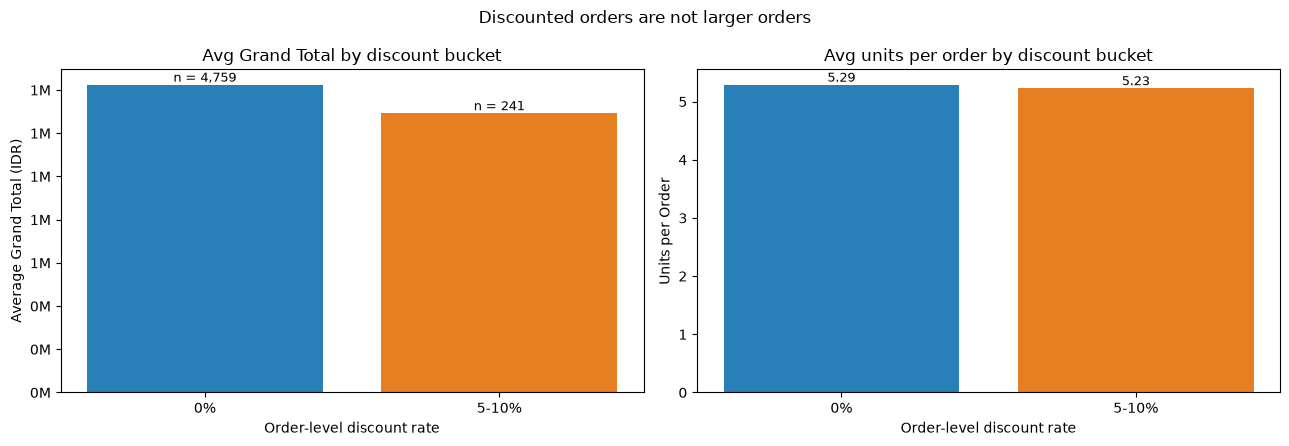

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].bar(discount_econ['discount_bucket'].astype(str), discount_econ['avg_grand_total'],
                   color=[PLOT_COLORS['cool'], PLOT_COLORS['warm']])
for b, n in zip(bars, discount_econ['orders']):
    axes[0].annotate(f'n = {int(n):,}', (b.get_x() + b.get_width() / 2, b.get_height()),
                     ha='center', va='bottom', fontsize=9)
axes[0].set_title('Avg Grand Total by discount bucket')
axes[0].set_ylabel('Average Grand Total (IDR)')
axes[0].set_xlabel('Order-level discount rate')
rupiah_axis(axes[0])

bars2 = axes[1].bar(discount_econ['discount_bucket'].astype(str), discount_econ['avg_units_per_order'],
                    color=[PLOT_COLORS['cool'], PLOT_COLORS['warm']])
for b, v in zip(bars2, discount_econ['avg_units_per_order']):
    axes[1].annotate(f'{v:.2f}', (b.get_x() + b.get_width() / 2, b.get_height()),
                     ha='center', va='bottom', fontsize=9)
axes[1].set_title('Avg units per order by discount bucket')
axes[1].set_ylabel('Units per Order')
axes[1].set_xlabel('Order-level discount rate')

fig.suptitle('Discounted orders are not larger orders', fontsize=12)
plt.tight_layout()
plt.show()

### Observation

Discounting in this dataset is rare and uniform. `Discount (%)` takes only **two values — 0 and 10**.
Just **4.8%** of line items (722 of 15,000) and **4.8%** of orders (241 of 5,000) carry any discount
at all; 95.2% of orders sit at a zero order-level discount rate, so every discounted order falls into
a single 5–10% bucket.

Comparing the two cohorts: discounted orders average a Grand Total of **Rp 1,292,861** against
**Rp 1,424,532** for undiscounted orders — **9.2% lower**, not higher. Units per order are 5.23
versus 5.29. At order level, corr(discount rate, units per order) = **−0.007** and corr(discount
rate, Grand Total) = **−0.050**; both are negligible by Cohen's thresholds.

Order economics more broadly are notably flat. The top 10% of orders by value hold **17.6%** of total
order value, against 10% under a perfectly even distribution — so there is no high-value cohort
carrying the business. Every order contains 2–4 line items, and average order value varies by only
**9.9%** across the five order statuses (Rp 1,339,425 for Cancelled to Rp 1,472,556 for Pending)
even though 31.4% of orders never reach Completed.

### Interpretation

**The available evidence does not show that higher discount exposure is associated with larger or
more valuable orders.** The correlations are negligible and the point difference runs mildly in the
opposite direction. That is a real result, and it is worth stating plainly rather than reworking:
in this dataset, discounting is not functioning as a basket-building mechanism.

It is equally important to be clear about *why* the evidence is limited. With a single 10% discount
level applied to under 5% of orders, this dataset does not contain the variation needed to test a
discount–basket relationship properly. The honest conclusion is therefore twofold: no positive
association is observed, and the design of the current discount programme is such that one could not
have been detected reliably even if it existed.

The flat order-value distribution and the flat average order value across statuses point the same
way: this is a business of many similar-sized baskets. The 31.4% non-completion rate is a **volume
and process phenomenon, not a value phenomenon** — cancelled and returned orders are ordinary-sized
orders, so there is no "high-value orders are the ones failing" pattern to chase.

**A note on conflicting evidence.** `03_eda.ipynb` §16.3 reported a moderate positive correlation
(0.453) between average discount rate and AOV *across the five platforms*. That is computed on five
aggregated points, whereas the order-level correlations above are computed on 5,000 orders. Where the
two disagree, the order-level result is the one this notebook relies on; the platform-level figure is
directional at best and is not treated as evidence of a discount–AOV relationship.

### Business Implication

Discount depth is not currently a lever this business can be shown to be pulling, and basket-value
initiatives should not be evaluated against discount intensity as if it were one. Before any decision
to expand or withdraw discounting, the 241 discounted orders warrant examination as a **separate
cohort** — what they have in common, and why those orders received the discount — because the current
programme is too small and too uniform to have generated an answer on its own.

Separately, because non-completion is value-neutral, it should be tracked as an **order-count rate**;
a value-at-risk framing would add complexity without adding information.

### Caveat

This is observational. Nothing here establishes that discounts caused, or failed to cause, any change
in order size — the discounted orders were not randomly assigned, and the dataset contains no record
of why any order was discounted, no campaign identifier and no pre/post comparison. The direction of
the observed difference (discounted orders being smaller) is equally consistent with a selection
effect as with anything about the discount itself. The 241-order cohort is also small relative to the
4,759 undiscounted orders.

---
## 08. Insight 5 — Customer Rating

### Business Question
Does customer rating appear meaningfully associated with transaction economics, platform, or order
outcome — that is, can it be used as an operational signal?

In [ ]:
# Customer Rating is an order-level attribute (constant within Order ID), per 03_eda.ipynb section 5.3.
# Verified here before use, because reading it at line level would over-count multi-line orders.
assert (df.groupby('Order ID')['Customer Rating'].nunique() == 1).all(), \
    'Customer Rating is not constant within Order ID; the order-level treatment would be invalid.'

rating_value = order_df.groupby('Customer_Rating').agg(
    orders=('Order ID', 'nunique'),
    avg_grand_total=('Grand_Total', 'mean'),
    median_grand_total=('Grand_Total', 'median'),
).round(0).reset_index()

rating_platform = order_df.groupby('Platform').agg(
    avg_rating=('Customer_Rating', 'mean'), orders=('Order ID', 'nunique'),
).round(3).reset_index().sort_values('avg_rating', ascending=False)

rating_status = order_df.groupby('Order_Status').agg(
    avg_rating=('Customer_Rating', 'mean'), orders=('Order ID', 'nunique'),
).round(3).reset_index().sort_values('avg_rating', ascending=False)

rating_corr = order_df['Customer_Rating'].corr(order_df['Grand_Total'])

print('Order value by customer rating')
display(rating_value)
print('Average rating by platform (with order count)')
display(rating_platform)
print('Average rating by order status (with order count)')
display(rating_status)

print(f'corr(Customer Rating, Grand Total) = {rating_corr:.3f} ({cohen_r_label(rating_corr)})')
print(f"Average Grand Total across the five rating levels spans {rp(rating_value['avg_grand_total'].min())} "
      f"to {rp(rating_value['avg_grand_total'].max())} "
      f"({(rating_value['avg_grand_total'].max()/rating_value['avg_grand_total'].min()-1)*100:.1f}%).")
print(f"Platform rating spread: {rating_platform['avg_rating'].max() - rating_platform['avg_rating'].min():.3f} on a 1-5 scale.")
print(f"Status  rating spread: {rating_status['avg_rating'].max() - rating_status['avg_rating'].min():.3f} on a 1-5 scale.")
print(f"Overall mean rating: {order_df['Customer_Rating'].mean():.3f}; "
      f"{(order_df['Customer_Rating'] <= 3).mean()*100:.1f}% of orders are rated 3 or lower.")

Order value by customer rating


,Customer_Rating,orders,avg_grand_total,median_grand_total
0,1,1030,1416267.0,1359500.0
1,2,1031,1420633.0,1380000.0
2,3,911,1410209.0,1355000.0
3,4,1118,1417490.0,1355500.0
4,5,910,1426426.0,1365500.0


Average rating by platform (with order count)


,Platform,avg_rating,orders
0,FashionHub,3.073,455
4,Toko Fashion App,2.988,1753
1,FashionKita,2.981,1000
3,StyleMart,2.979,1134
2,OutfitNow,2.815,658


Average rating by order status (with order count)


,Order_Status,avg_rating,orders
4,Shipped,3.091,263
2,Pending,3.008,242
1,Completed,2.972,3430
0,Cancelled,2.935,371
3,Returned,2.916,694


corr(Customer Rating, Grand Total) = 0.004 (negligible)
Average Grand Total across the five rating levels spans Rp 1,410,209 to Rp 1,426,426 (1.1%).
Platform rating spread: 0.258 on a 1-5 scale.
Status  rating spread: 0.175 on a 1-5 scale.
Overall mean rating: 2.969; 59.4% of orders are rated 3 or lower.


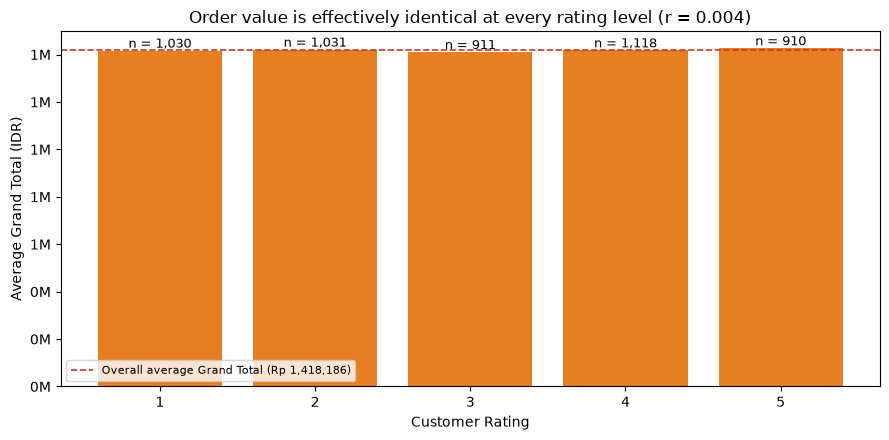

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(rating_value['Customer_Rating'].astype(str), rating_value['avg_grand_total'],
              color=PLOT_COLORS['warm'])
overall_gt = order_df['Grand_Total'].mean()
ax.axhline(overall_gt, color=PLOT_COLORS['alert'], linestyle='--', linewidth=1.2,
           label=f'Overall average Grand Total ({rp(overall_gt)})')
for b, n in zip(bars, rating_value['orders']):
    ax.annotate(f'n = {int(n):,}', (b.get_x() + b.get_width() / 2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.set_title(f'Order value is effectively identical at every rating level (r = {rating_corr:.3f})')
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Average Grand Total (IDR)')
rupiah_axis(ax)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Observation

Customer rating shows no meaningful association with order economics. corr(rating, Grand Total) =
**0.004** — negligible. Average Grand Total across the five rating levels spans Rp 1,410,209 to
Rp 1,426,426, a difference of **1.1%**, with each level backed by 910–1,118 orders.

Rating also barely varies across the dimensions it might be expected to track. Platform averages run
from 2.815 (OutfitNow) to 3.073 (FashionHub) — a spread of **0.258 on a 1–5 scale**. Averages by order
status run from 2.916 (Returned) to 3.091 (Shipped), a spread of 0.175; `Returned` orders are rated
0.056 below `Completed` orders. Overall, the mean rating is 2.97 and **59.4%** of orders are rated 3
or lower.

### Interpretation

**Customer rating shows limited association with order value in this dataset** — a legitimate finding
in its own right. It is not a leading or lagging indicator of transaction size, and it does not
separate platforms or order outcomes to any degree that would support a decision. The fact that
`Returned` orders are rated only 0.06 lower than `Completed` orders is notable: even the most obvious
expected relationship — a bad outcome producing a bad rating — is not visible at the order level.

The absolute level (mean 2.97 on a 1–5 scale, with 59.4% of orders at 3 or below) looks low, but this
notebook does not interpret it. There is no prior period, no competitor benchmark, no industry
reference and no rating methodology documented in the project, so there is no basis for calling 2.97
good or bad. Nor is there any free-text feedback, complaint record or rating timestamp that would
allow the number to be diagnosed.

> The available EDA does not provide sufficient evidence to explain the rating distribution or to link
> it to any business outcome.

### Business Implication

Rating should be treated as a **monitoring metric, not a driver metric**. It can sit on a dashboard as
a service-quality tile, but it should not be used to rank platforms, to explain sales differences, or
as a proxy for revenue impact — the evidence supports none of those uses. Any attempt to act on the
rating level would require instrumentation this dataset does not have.

### Caveat

Rating is observational and may be affected by factors this dataset does not record: who leaves a
rating and who does not, when the rating was captured relative to delivery, and whether the scale is
applied consistently across platforms. A weak observed association is not evidence that customer
experience is unimportant — only that this particular field carries no usable signal about
transaction economics here.

---
## 09. Prioritised Business Insights

Insights are ranked on three criteria together: **evidence strength** (how robust the underlying
result is), **business relevance** (whether it touches a real decision), and **actionability**
(whether something can be done or monitored as a result).

Four insights meet that standard. Two of the five analysis areas above did not, and are excluded
below with the reason stated.

| Priority | Business Insight | Evidence | Why It Matters |
|:--:|---|---|---|
| **1** | Recorded sales at product level are **price-led, not volume-led** — the products that move the most units are not the products that generate the most sales | corr(avg unit price, sales) = **0.864**; corr(quantity, sales) = **−0.565**; only **2 of the top 8** by sales are also top 8 by quantity; Gamis leads sales (Rp 619.2M, 8.9%) on 1,191 units while Kaos Pendek leads units (1,882) at Rp 204.1M, ranking 19th of 20 on sales | A single "best sellers" list will systematically misdirect one of two different decisions. Revenue planning and stock-depth planning are reading different products, and the two rankings agree only a quarter of the time |
| **2** | Platform sales leadership is a **volume outcome**, and roughly a third of the business runs through one platform | corr(order count, sales) = **1.000** vs corr(AOV, sales) = 0.218 across 5 platforms; sales range 3.92× while AOV ranges 1.03× (Rp 1,367,215–1,414,191); units per order 5.16–5.36; Toko Fashion App = 35.1% of orders and 35.3% of sales | Channel management should be framed around reach and order acquisition, not basket quality — and single-channel concentration is a dependency that a sales chart alone leaves implicit |
| **3** | **31.4% of orders never reach `Completed`**, and that share is value-neutral across the order-size distribution | 1,570 of 5,000 orders non-completed, holding Rp 2,181,031,200 = **31.3% of recorded sales**; Returned alone is 694 orders (13.9%); average Grand Total by status spans only Rp 1,339,425–1,472,556 (9.9%) | Every sales figure in this project overstates realised activity by roughly a third unless qualified. Because value is uniform across statuses, non-completion is a process and volume issue, not a high-value-order issue |
| **4** | Discounting is **rare, uniform, and not associated with larger baskets** | 95.2% of orders carry no discount; `Discount (%)` has only two values (0, 10); 4.8% of line items discounted; discounted orders avg Rp 1,292,861 vs Rp 1,424,532 (**−9.2%**); corr(rate, units) = −0.007, corr(rate, Grand Total) = −0.050 | Discount depth cannot currently be shown to function as a basket-building lever, so basket-value initiatives should not be measured against it — and the programme is too narrow to have proven otherwise |

### Excluded from the prioritised list

**Geographic performance (Insight 3)** — *excluded: valid observation, no prioritisable action.*
The finding is genuine and worth recording: sales are spread thinly across 38 cities, with the top
city at 4.86% against an even split of 2.63% and the top 3 at 13.1% against 7.9%. But precisely
because there is no concentration, there is no city whose performance can move the aggregate, and at
an average of 132 orders per city the per-city samples are too thin to support a differentiated plan.
The evidence supports treating geography as a monitoring dimension; it does not support prioritising
any city, and the dataset contains nothing (demographics, spend, coverage) that would let a
geographic recommendation be grounded.

**Customer rating (Insight 5)** — *excluded: no association strong enough to act on.*
corr(rating, Grand Total) = 0.004, platform spread 0.258 and status spread 0.175 on a 1–5 scale.
Rating does not separate platforms, statuses or order values. The absolute level (mean 2.97, 59.4% of
orders at 3 or below) is the one element that might warrant attention, but this project has no
benchmark, no prior period and no qualitative feedback field, so any recommendation built on it would
be assumption rather than evidence. It is retained as a monitoring metric only.

Three of the four prioritised insights above would also have been defensible on their own; a fifth
was not added for symmetry.

---
## 10. Business Recommendations

Each recommendation traces to one prioritised insight and carries the KPI that would show whether the
situation is changing. Because the analysis is observational, recommendations are framed as *maintain*,
*monitor*, *report* and *investigate* — not as instructions to change price, discount level, product
range, city footprint or platform strategy, none of which this evidence can support.

---

### R1 — Maintain and reconcile two separate product rankings

**From Insight 1 (Priority 1).**

**Recommendation**: maintain a revenue-contribution ranking and a unit-movement ranking as two
distinct product views, and state explicitly which one any given decision is reading from. Reconcile
them — rather than merging them — before merchandising, promotional-slotting or stock-depth decisions.

**Business rationale**: the two rankings overlap on only 2 of 8 products, and across the catalogue
recorded sales track unit price (r = 0.864) while moving *inversely* with quantity (r = −0.565). A
single "top products" list will therefore be wrong for one of the two decision types it gets used for.

**Metrics to monitor**:
- Revenue contribution % per product (currently: top 5 = 34.5%, top 10 = 60.9% of 20 products)
- Units sold per product
- **Overlap count** between top-N by revenue and top-N by units (currently 2 of 8) — a single number
  that shows whether the two rankings are converging or diverging

**Explicitly not recommended**: any pricing action. The price–sales correlation describes products as
they were sold; it is not an elasticity estimate, and with no cost data a high-revenue product cannot
be identified as a profitable one.

---

### R2 — Report channel performance on order volume, and track top-platform concentration

**From Insight 2 (Priority 2).**

**Recommendation**: make order count the primary channel-performance measure in reporting, and add
top-platform share of orders as a standing concentration measure. Retain platform AOV as a stability
check rather than as a ranking device.

**Business rationale**: the sales ranking and the order-count ranking are the same ranking
(r = 1.000), so a sales-based channel chart adds no information over a volume-based one. Platform AOV
varies by 3.4% end to end, which is small enough that ranking platforms on it would present noise as
a finding. Meanwhile 35.1% of orders running through one platform is a real dependency that neither
chart currently states.

**Metrics to monitor**:
- Orders per platform, and each platform's share of total orders (currently 9.1%–35.1%)
- Top-platform share of orders — the concentration measure (currently 35.1%)
- Platform Sales AOV — monitored for stability against the Rp 1,367,215–1,414,191 band observed here,
  not used to rank

**Explicitly not recommended**: shifting volume between platforms, or renegotiating channel terms on
the basis of these figures. The dataset holds no commission, fulfilment-cost or acquisition-cost
information, so it cannot say which channel is more valuable — only which is larger.

---

### R3 — Report sales with a status qualifier by default, and track non-completion as a count rate

**From Insight 3 (Priority 3).**

**Recommendation**: present recorded sales alongside a Completed-only figure everywhere it appears,
rather than as a single number, and monitor non-completion as an order-count rate. Investigate further
whether non-completion concentrates in particular platforms or cities — a question `03_eda.ipynb` §18
raised and did not test.

**Business rationale**: 31.3% of recorded sales (Rp 2,181,031,200) sits outside `Completed`, which is
large enough to change how any breakdown is read. Because average order value is essentially uniform
across statuses (a 9.9% band), a value-weighted "revenue at risk" view would carry no information the
simple count rate does not already give — and would imply a concentration in large orders that the
data does not show.

**Metrics to monitor**:
- Completed order rate (currently 68.6%) and Returned order rate (currently 13.9%)
- Recorded sales vs Completed-only recorded sales, shown together
- Non-completion rate broken down by platform and by city — *to be established*, not yet measured

**Explicitly not recommended**: treating the Rp 2.18B in non-completed orders as "lost revenue". That
framing assumes every such order would otherwise have converted at full value, which nothing in this
dataset supports, and `Pending` and `Shipped` orders (10.1% of orders) are snapshots of in-flight
states rather than failures.

---

### R4 — Investigate the discounted cohort before changing the discount programme

**From Insight 4 (Priority 4).**

**Recommendation**: examine the 241 discounted orders as a distinct cohort — what they share, and on
what basis the discount was applied — before either expanding or withdrawing discounting. Do not treat
discount depth as a basket-building lever in planning until there is evidence that it functions as one.

**Business rationale**: with a single 10% discount level applied to 4.8% of orders, the programme has
not generated the variation needed to detect a discount–basket relationship. What the data does show
is that discounted orders are 9.2% *smaller* on average (Rp 1,292,861 vs Rp 1,424,532) with negligible
correlations (−0.007 on units, −0.050 on order value) — so there is no observed basis for expecting
discounting to raise basket size here.

**Metrics to monitor**:
- Share of orders discounted (currently 4.8%) and share of line items discounted (currently 4.8%)
- Average order-level discount rate (currently 0.48%)
- AOV and units per order, split by discounted vs undiscounted cohort — reported as a paired
  comparison so any change in the gap is visible

**Explicitly not recommended**: increasing, decreasing or removing discounts on the strength of these
numbers. The cohort was not randomly assigned and the dataset records no reason for any discount, so
the observed difference is as consistent with a selection effect as with a discount effect. A
deliberate test with varied discount levels would be required to answer the question properly.

---
## 11. Limitations

These are the constraints that actually bear on the conclusions above. Each is stated with what it
prevents, not as a generic disclaimer.

**Observational data — associations only.** This is one year of transaction records with no
experiment, no control group and no intervention log. Every relationship reported here is an
association. In particular, the discount finding (Insight 4) cannot distinguish a discount effect from
a selection effect, and the platform finding (Insight 2) cannot say whether volume produces sales or
both follow from something unobserved.

**No `Customer ID`.** The dataset has 395 unique `Customer Name` values, but `01_data_understanding.ipynb`
established that the same name appears across multiple cities for the large majority of names, so
names cannot be resolved to customers. Retention, repeat-purchase rate, purchase frequency and
customer lifetime value are therefore **not analysable** in this project, and no recommendation above
depends on them.

**No cost or margin data.** `Total Sales` and `Grand Total` are revenue measures, not profit. This is
why R1 stops short of any pricing action despite the strong price–sales correlation, and why R2 makes
no claim about which platform is more valuable. **No product, platform or city in this project can be
described as "most profitable."**

**No marketing, campaign or promotion data.** There is no campaign identifier, spend figure or
promotion calendar. Nothing here can attribute sales differences between platforms, cities or months
to promotional activity — including the discounted-order cohort, whose discounts have no recorded
cause.

**Geographic context is absent.** The dataset carries city names and nothing else about those cities:
no population, income, demographic or store-coverage data. City-level differences therefore cannot be
attributed to purchasing power, market maturity or customer preference, which is the primary reason
geography was excluded from the prioritised insights.

**Rating is observational and undiagnosable here.** There is no record of who rates and who does not,
no rating timestamp relative to delivery, and no free-text feedback. The low absolute level (mean 2.97,
59.4% of orders at 3 or below) is reported without interpretation because the dataset offers no way to
interpret it.

**Single year — no seasonality.** Coverage is exactly Jan–Dec 2025. `03_eda.ipynb` §7 showed monthly
sales, orders, units and AOV are all flat (CoV 1.9%–4.7%), but with one year of data recurring
seasonal patterns cannot be established at all. No recommendation above assumes a seasonal effect.

**Order status is a snapshot, not a lifecycle.** There are no status-transition timestamps, so it is
not possible to tell whether `Pending` and `Shipped` orders (10.1% of orders) will convert to
`Completed` or to `Cancelled`. The 31.4% non-completion figure in Insight 3 should be read with that
in mind.

**`Category` is analyst-derived and `Gender` is a product attribute.** `03_eda.ipynb` §12 flagged both:
`Category` does not exist in the source data and was built by mapping the 20 products into five
groups, and `Gender` describes the product, not the customer. The strong Category×Gender skew (4 of 5
categories above 65/35) is a property of that taxonomy — Dresses are 100% Wanita and Outerwear 100%
Pria by construction — and says nothing about customer demographics. Nothing above is built on it.

**Material labels are unresolved.** `03_eda.ipynb` §12.2 flagged that `Cotton` (2.3% of sales) and
`Katun` (13.0%) appear as separate material values. Whether these represent the same material was not
resolved, so this notebook draws no material-level conclusions.

**Basket structure is unusually uniform.** Every order carries exactly 2, 3 or 4 line items
(1,500 / 2,000 / 1,500 orders), and the top 10% of orders by value hold only 17.6% of total value.
There is no long tail of very small or very large orders, which limits what basket-expansion or
high-value-customer analysis this dataset can support.

**Small n on several aggregate correlations.** The platform correlations are computed across 5 points
and the product correlations across 20. They are reported with their coefficients and are treated as
directional descriptions of these observations, not as statistically robust estimates.

---
## 12. Next Steps

```
Business Insights  ->  Power BI Dashboard  ->  Executive Reporting
```

The dashboard should carry the metrics that the prioritised insights actually depend on, and leave out
metrics this analysis has shown carry no differentiating signal. Metrics are grouped by the insight
that justifies them.

### Primary — metrics tied to a prioritised insight

| Metric | Grain | Insight it serves | Note for the dashboard |
|---|---|---|---|
| Recorded sales, with a **Completed-only** toggle | order | Priority 3 | Never show a single unqualified sales figure — 31.3% sits outside `Completed` |
| Completed order rate / Returned order rate | order | Priority 3 | Count-based, not value-weighted (order value is uniform across statuses) |
| Order count | order | Priority 2, 3 | Use `Order ID` distinct count; the dataset is order-item grain |
| Orders by platform + **top-platform share of orders** | order | Priority 2 | The concentration measure, shown as a number rather than implied by a bar chart |
| Product revenue contribution % **and** units sold, side by side | line item | Priority 1 | The two rankings must be visible together; showing either alone is the failure mode this insight identifies |
| Sales AOV | order | Priority 2 | Stability check against the Rp 1,367,215–1,414,191 platform band — not a ranking device |
| Units per order | order | Priority 1, 4 | Currently 5.29 overall, 5.16–5.36 by platform |
| Share of orders discounted | order | Priority 4 | Currently 4.8%; paired with AOV split by discounted vs undiscounted cohort |

### Secondary — context and monitoring only

| Metric | Why it is secondary |
|---|---|
| Geographic sales by city | No concentration to act on (top city 4.86%, even split 2.63%); useful for coverage and anomaly detection, not for targeting |
| Customer rating | corr with order value = 0.004; monitoring tile only, not a ranking or explanatory metric |
| Category / material mix | `Category` is analyst-derived and the `Cotton`/`Katun` labelling is unresolved; present with those caveats or not at all |

### Deliberately not on the dashboard

Profitability or margin by any dimension (no cost data), customer retention or repeat-purchase rate
(no `Customer ID`), year-on-year or seasonal comparisons (single year of data), and "revenue at risk"
from cancellations (assumes conversion the data does not support).

### Open questions to carry forward

`03_eda.ipynb` §18 raised several questions this notebook could not close on the available evidence:

1. **Does non-completion concentrate in specific platforms or cities?** Directly relevant to R3, and
   not tested in the EDA. This is the highest-value next analysis because it would turn a flat 31.4%
   rate into something targetable.
2. **What distinguishes the 241 discounted orders?** Relevant to R4; requires the discount rationale,
   which this dataset does not record.
3. **Does product or material mix explain platform and city sales differences?** Would need the
   `Cotton`/`Katun` labelling resolved first.

Each of these needs either a new analysis pass or additional data — cost/margin, campaign records, a
customer identifier, or a second year of transactions. Until then, the four prioritised insights above
represent what this dataset can honestly support.